# Variables categóricas en regresión: de la dummy a la regresión logística
### Síntesis Semana 7 + Semana 8 · FIA 94103 · Fundamentos de IA

Los notebooks de la Semana 7 (`Semana_7/Matematicas/regresion_lineal_paso_a_paso.ipynb`) trabajaron la regresión lineal con variables **numéricas** (`math score`, `reading score`, `writing score`). Pero `StudentsPerformance.csv` también trae variables **categóricas**: `gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`. Este notebook responde la pregunta que quedó pendiente: **¿cómo entran esas columnas de texto a una ecuación matemática?**

Seguimos el mismo hilo conceptual que ya viste en las hojas de teoría:

- `Semana_7/01_Regresion_lineal_conceptos_basicos.md` (sección 5: el ejemplo de `gender` como variable dummy)
- `Semana_7/02_Cuando_utilizar_modelo_regresion_lineal.md` (sección 1.2 y 1.3: cuántas columnas dummy agrega cada categórica, y el riesgo de tener demasiadas)
- `Semana_8/01_Regresion_logistica_conceptos_basicos.md` (regresión logística: cuando lo que queremos predecir, no solo lo que usamos para predecir, es categórico)
- `Semana_8/04_Regresion_Lineal_Vs_Regresion_Logistica.md` (comparación lado a lado)

**Contenido:**
1. Explorar las variables categóricas del dataset
2. Categórica binaria como variable dummy (repaso Semana 7): `gender` → `writing score`
3. Categórica con varios niveles: *one-hot encoding* de `race/ethnicity` → `math score`
4. La "trampa de las dummies" (dummy trap) y por qué se usa *k-1* columnas
5. Mezclar categóricas + numéricas en un mismo modelo: `parental level of education` + `reading score` → `writing score`
6. Cuidado con la multicolinealidad al combinar muchas categóricas
7. Cuando la variable a **predecir** es categórica: regresión logística con predictores mixtos
8. Interpretar coeficientes categóricos con el *odds ratio*
9. Evaluar el clasificador: matriz de confusión, exactitud, precisión, sensibilidad
10. Comparación final y ejercicios
11. Conclusiones

## 0. Librerías y datos

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

plt.rcParams['figure.figsize'] = (7, 5)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv('../StudentsPerformance.csv')
df.columns = [c.strip() for c in df.columns]
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Explorar las variables categóricas

Antes de convertir nada en números, miramos qué categorías trae cada columna y cuántos estudiantes hay en cada una. Esto es exactamente el **paso 1 (explorar)** del flujo que ya conoces de la Semana 7 y 8: no se ajusta ningún modelo sin entender antes los datos.

In [2]:
categoricas = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in categoricas:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- gender ---
gender
female    518
male      482
Name: count, dtype: int64

--- race/ethnicity ---
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

--- parental level of education ---
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

--- lunch ---
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

--- test preparation course ---
test preparation course
none         642
completed    358
Name: count, dtype: int64



**Lectura rápida:** `gender` y `test preparation course` y `lunch` tienen solo **2 niveles** (son las más simples de incorporar). `race/ethnicity` tiene **5 niveles** (`group A`…`group E`) y `parental level of education` tiene **6 niveles**. Esto ya lo anticipaba la tabla de `02_Cuando_utilizar_modelo_regresion_lineal.md`: cada nivel de más es una columna dummy de más.

## 2. Categórica binaria como variable dummy (repaso Semana 7)

Con **2 niveles**, la conversión es la más simple posible: se crea **una sola** columna 0/1. Usamos `gender` para predecir `writing score`, exactamente el ejemplo del Ejercicio 7 de `01_Regresion_lineal_conceptos_basicos.md`.

$$\text{writing score} = b_0 + b_1 \times \text{gender\_dummy}_{(1=\text{mujer})}$$

Antes de comparar los dos grupos con una prueba *t*, revisamos el supuesto de **homogeneidad de varianzas** (Levene) — es el mismo paso 6 ("revisar supuestos") del flujo de regresión.

In [3]:
hombres = df.loc[df['gender'] == 'male', 'writing score']
mujeres = df.loc[df['gender'] == 'female', 'writing score']

levene = stats.levene(hombres, mujeres)
print(f'Levene -> estadístico={levene.statistic:.4f}, p-value={levene.pvalue:.4f}')

ttest = stats.ttest_ind(hombres, mujeres, equal_var=True)
print(f't-test  -> t={ttest.statistic:.4f}, p-value={ttest.pvalue:.2e}')

Levene -> estadístico=0.0069, p-value=0.9336
t-test  -> t=-9.9796, p-value=2.02e-22


In [4]:
df['gender_dummy'] = (df['gender'] == 'female').astype(int)

X = sm.add_constant(df['gender_dummy'])
modelo_dummy = sm.OLS(df['writing score'], X).fit()
print(modelo_dummy.summary())

                            OLS Regression Results                            
Dep. Variable:          writing score   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     99.59
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           2.02e-22
Time:                        19:01:51   Log-Likelihood:                -4091.9
No. Observations:                1000   AIC:                             8188.
Df Residuals:                     998   BIC:                             8198.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           63.3112      0.660     95.879   

**Verificación clave:** `const` (b0) debe coincidir con el promedio de los hombres (grupo codificado como 0), y `gender_dummy` (b1) debe coincidir con la diferencia de promedios mujeres − hombres.

In [5]:
medias = df.groupby('gender')['writing score'].mean()
print(medias)
print(f"\nb0 (modelo) = {modelo_dummy.params['const']:.4f}   vs. media hombres = {medias['male']:.4f}")
print(f"b1 (modelo) = {modelo_dummy.params['gender_dummy']:.4f}   vs. diferencia (mujeres-hombres) = {medias['female']-medias['male']:.4f}")

gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64

b0 (modelo) = 63.3112   vs. media hombres = 63.3112
b1 (modelo) = 9.1560   vs. diferencia (mujeres-hombres) = 9.1560


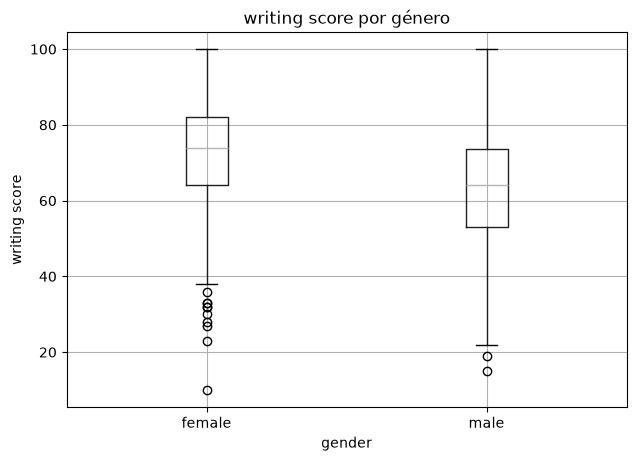

In [6]:
df.boxplot(column='writing score', by='gender')
plt.title('writing score por género')
plt.suptitle('')
plt.ylabel('writing score')
plt.show()

Como Levene no rechazó H0 (varianzas parecidas) y el p-value del t-test es prácticamente cero, concluimos: **la variable dummy `gender_dummy` sí aporta información real** sobre `writing score` — las mujeres sacan, en promedio, ~9.16 puntos más. La regresión con la dummy y la prueba *t* clásica son, literalmente, la misma pregunta respondida de dos formas equivalentes.

## 3. Categórica con varios niveles: *one-hot encoding*

Cuando una categórica tiene **más de 2 niveles**, una sola columna 0/1 no alcanza. `race/ethnicity` tiene 5 niveles (`group A` … `group E`); se crean **k − 1 = 4** columnas dummy (esto se llama *one-hot encoding*). Cada columna es "¿pertenece a este grupo? (1) o no (0)"; el nivel que **no** recibe columna propia (aquí, `group A`) queda como **categoría de referencia**, y todos los demás coeficientes se interpretan **en comparación con ella**.

`pandas.get_dummies(..., drop_first=True)` hace exactamente esta conversión.

In [7]:
race_dummies = pd.get_dummies(df['race/ethnicity'], drop_first=True, dtype=int)
race_dummies.head()

,group B,group C,group D,group E
0,1,0,0,0
1,0,1,0,0
2,1,0,0,0
3,0,0,0,0
4,0,1,0,0


In [8]:
X_race = sm.add_constant(race_dummies)
modelo_race = sm.OLS(df['math score'], X_race).fit()
print(modelo_race.summary())

                            OLS Regression Results                            
Dep. Variable:             math score   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     14.59
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.37e-11
Time:                        19:01:52   Log-Likelihood:                -4108.8
No. Observations:                1000   AIC:                             8228.
Df Residuals:                     995   BIC:                             8252.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.6292      1.565     39.373      0.0

**Cómo se lee esta tabla** (misma lógica de p-value y H0/H1 que en `01_...md`, sección 2):

- `const` = promedio de `math score` en `group A` (la referencia): **61.63**.
- Cada fila (`group B`, `group C`, `group D`, `group E`) es la **diferencia respecto a `group A`**. Por ejemplo, `group E` tiene en promedio **+12.19** puntos más que `group A` (p < 0.001, muy significativo).
- `group B` (+1.82, p = 0.337) y `group C` (+2.83, p = 0.110) **no** son significativamente distintos de `group A` con α = 0.05: no hay evidencia suficiente de que su promedio real sea diferente.
- El R² (0.055) es bajo: el grupo étnico por sí solo explica poco de la variación en `math score` — es un predictor débil comparado con `reading score` (R² ≈ 0.67, visto en el notebook de la Semana 7).

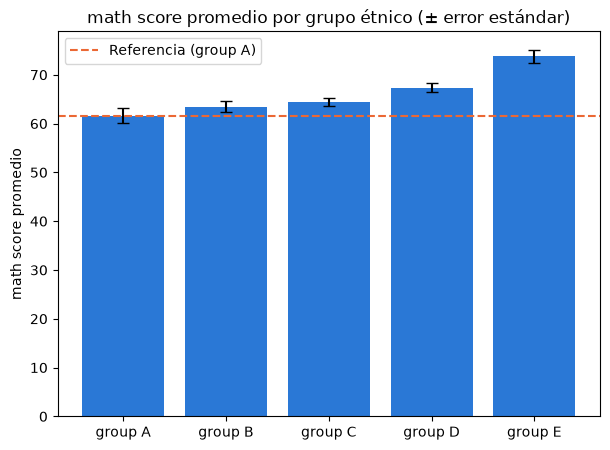

In [9]:
orden = sorted(df['race/ethnicity'].unique())
medias_race = df.groupby('race/ethnicity')['math score'].mean().reindex(orden)
errores = df.groupby('race/ethnicity')['math score'].sem().reindex(orden)

plt.bar(medias_race.index, medias_race.values, yerr=errores.values, capsize=4, color='#2a78d6')
plt.axhline(medias_race['group A'], color='#eb6834', linestyle='--', label='Referencia (group A)')
plt.ylabel('math score promedio')
plt.title('math score promedio por grupo étnico (± error estándar)')
plt.legend()
plt.show()

## 4. La "trampa de las dummies" (dummy trap)

¿Por qué **k − 1** columnas y no **k**? Si `gender` (2 niveles) se convirtiera en **dos** columnas (`male`, `female`) más el intercepto, el modelo quedaría con información redundante: `male + female = 1` siempre, así que una columna es perfectamente predecible a partir de la otra (y del intercepto). Esto se llama **multicolinealidad perfecta** o *dummy trap*, y hace que el sistema de ecuaciones de mínimos cuadrados no tenga una solución única.

Lo comprobamos calculando el **rango** de la matriz de diseño: con 3 columnas (intercepto + 2 dummies completas) esperaríamos rango 3 si fueran independientes, pero obtenemos rango 2.

In [10]:
trampa = pd.get_dummies(df['gender'], dtype=int)  # sin drop_first: las 2 columnas completas
X_trampa = sm.add_constant(trampa)
print(X_trampa.head())
print(f"\nColumnas: {X_trampa.shape[1]}   Rango de la matriz: {np.linalg.matrix_rank(X_trampa.values.astype(float))}")
print('El rango es menor que el número de columnas: hay una columna redundante (dummy trap).')

   const  female  male
0    1.0       1     0
1    1.0       1     0
2    1.0       1     0
3    1.0       0     1
4    1.0       0     1

Columnas: 3   Rango de la matriz: 2
El rango es menor que el número de columnas: hay una columna redundante (dummy trap).


Por eso siempre se deja **una categoría fuera** como referencia (`drop_first=True`): con *k − 1* columnas, la matriz ya no tiene esa redundancia, y el intercepto puede interpretarse limpiamente como "el promedio de la categoría de referencia".

## 5. Mezclar categóricas + numéricas en un mismo modelo

Un modelo real casi nunca usa un solo tipo de variable. Extendemos el modelo de la Semana 7 (`writing score` a partir de `reading score`) agregando `parental level of education` (6 niveles → 5 dummies, referencia = `associate's degree`, la primera en orden alfabético):

$$\text{writing} = b_0 + b_1\cdot\text{reading} + b_2\cdot\text{bachelor} + b_3\cdot\text{highschool} + b_4\cdot\text{master} + b_5\cdot\text{somecollege} + b_6\cdot\text{somehighschool}$$

In [11]:
edu_dummies = pd.get_dummies(df['parental level of education'], drop_first=True, dtype=int)
X_mixto = pd.concat([df['reading score'], edu_dummies], axis=1)
X_mixto = sm.add_constant(X_mixto)

modelo_mixto = sm.OLS(df['writing score'], X_mixto).fit()
print(modelo_mixto.summary())

                            OLS Regression Results                            
Dep. Variable:          writing score   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1787.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:01:53   Log-Likelihood:                -2905.4
No. Observations:                1000   AIC:                             5825.
Df Residuals:                     993   BIC:                             5859.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3665      0.75

**Interpretación:**

- `reading score` sigue siendo, con enorme diferencia, el predictor más fuerte (`b1 ≈ 0.98`, p ≈ 0).
- Con `reading score` ya en el modelo, el nivel educativo de los padres aporta un efecto **pequeño pero medible**: tener padres con `bachelor's degree` o `master's degree` se asocia con **+1.4** puntos extra de `writing score` (frente a `associate's degree`, controlando por lectura); `high school` y `some high school` se asocian con **~1.1 a 1.3 puntos menos**.
- El R² subió de 0.911 (solo `reading score`, Semana 7) a **0.915**: una mejora pequeña — el mismo patrón de "agregar variables casi nunca baja el R², pero no siempre vale la complejidad extra" que ya viste en `02_Cuando_utilizar_modelo_regresion_lineal.md`, sección 2.2.

## 6. Cuidado con la multicolinealidad al combinar muchas categóricas

Cada categórica de más multiplica las columnas del modelo. Si combináramos las 4 categóricas de una vez (`gender`, `race/ethnicity`, `parental level of education`, `lunch`), pasaríamos de 4 columnas originales a muchas más columnas dummy — la advertencia exacta de la sección 1.3 de `02_Cuando_utilizar_modelo_regresion_lineal.md`.

In [12]:
resumen_niveles = pd.DataFrame({
    'variable': categoricas,
    'niveles': [df[c].nunique() for c in categoricas],
})
resumen_niveles['columnas dummy (k-1)'] = resumen_niveles['niveles'] - 1
print(resumen_niveles)
print(f"\nSi se meten las 4 categóricas juntas: {resumen_niveles['columnas dummy (k-1)'].sum()} columnas dummy nuevas, para solo {len(df)} estudiantes.")

                      variable  niveles  columnas dummy (k-1)
0                       gender        2                     1
1               race/ethnicity        5                     4
2  parental level of education        6                     5
3                        lunch        2                     1
4      test preparation course        2                     1

Si se meten las 4 categóricas juntas: 12 columnas dummy nuevas, para solo 1000 estudiantes.


Y no es solo cuestión de cantidad: si dos predictoras (categóricas o numéricas) están muy correlacionadas entre sí, el modelo no puede "repartir" bien el efecto entre ellas. Repetimos la matriz de correlación de las tres notas numéricas — el mismo ejemplo de `reading score` vs. `writing score` (0.95) que se usa como caso de multicolinealidad en ambas semanas.

In [13]:
correlaciones = df[['math score', 'reading score', 'writing score']].corr()
print(correlaciones.round(2))

               math score  reading score  writing score
math score           1.00           0.82           0.80
reading score        0.82           1.00           0.95
writing score        0.80           0.95           1.00


**Regla práctica** (checklist de `02_...md`, sección 3): antes de meter varias categóricas juntas, revisa cuántas columnas dummy suman en total y si alguna es redundante con otra variable ya en el modelo. Menos columnas, bien elegidas, casi siempre generan un modelo más estable e interpretable que meterlas todas.

## 7. Cuando lo que hay que predecir es categórico: regresión logística

Hasta aquí, la variable a predecir (`Y`) siguió siendo numérica (`writing score`, `math score`); las categóricas solo entraron como **predictoras** (`X`). Pero en la Semana 8 vimos el otro caso: cuando la variable a predecir **también** es categórica y binaria — aquí, "¿aprueba matemáticas?" (`math score >= 60`).

Repetimos el modelo de `01_Regresion_logistica_conceptos_basicos.md`, pero ahora con predictores **mixtos**: uno numérico (`reading score`) y dos categóricos (`gender_dummy`, `test_prep_dummy`) — algo que la hoja de teoría no desarrolla en detalle y que es el punto central de este notebook.

$$z = b_0 + b_1\cdot\text{reading} + b_2\cdot\text{gender\_dummy} + b_3\cdot\text{test\_prep\_dummy} \qquad P(Y=1) = \frac{1}{1+e^{-z}}$$

In [14]:
df['aprueba_mate'] = (df['math score'] >= 60).astype(int)
df['test_prep_dummy'] = (df['test preparation course'] == 'completed').astype(int)

print(df['aprueba_mate'].value_counts())

aprueba_mate
1    677
0    323
Name: count, dtype: int64


In [15]:
X_log = df[['reading score', 'gender_dummy', 'test_prep_dummy']]
X_log = sm.add_constant(X_log)
y_log = df['aprueba_mate']

modelo_logit = sm.Logit(y_log, X_log).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:           aprueba_mate   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                  0.5690
Time:                        19:01:53   Log-Likelihood:                -271.12
converged:                       True   LL-Null:                       -629.11
Covariance Type:            nonrobust   LLR p-value:                7.204e-155
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -14.6562      1.049    -13.972      0.000     -16.712     -12.600
reading score       0.2668      0.018     14.506      0.000       0.231       0.303
gender_dummy       -3.4180      

## 8. Interpretar coeficientes categóricos con el *odds ratio*

Igual que en `01_Regresion_logistica_conceptos_basicos.md` (sección 2), cada `b` se interpreta mejor como **odds ratio** ($e^{b}$): cuánto se multiplican los momios del evento por cada unidad de esa variable.

In [16]:
odds_ratios = np.exp(modelo_logit.params)
tabla_or = pd.DataFrame({'coeficiente (b)': modelo_logit.params, 'odds ratio (e^b)': odds_ratios, 'p-value': modelo_logit.pvalues})
tabla_or.round(4)

,coeficiente (b),odds ratio (e^b),p-value
const,-14.6562,0.0000,0.0000
reading score,0.2668,1.3058,0.0000
gender_dummy,-3.4180,0.0328,0.0000
test_prep_dummy,-0.5056,0.6031,0.0376


**Lectura de cada predictor** (todos con p < 0.05, es decir, significativos):

- `reading score`: OR ≈ 1.31 → por cada punto extra de lectura, los momios de aprobar matemáticas se multiplican por ~1.31 (suben ~31%), manteniendo fijos género y preparación.
- `gender_dummy` (1 = mujer): OR ≈ 0.033 → **manteniendo igual el puntaje de lectura**, los momios de aprobar matemáticas para una mujer son, en promedio, una fracción pequeña de los de un hombre. **Importante:** esto no contradice que las mujeres tengan mejor `writing`/`reading` en promedio (sección 2) — es un efecto *distinto*, específico de matemáticas y *condicionado* a un mismo nivel de lectura. Es un buen ejemplo real de por qué hay que leer cada coeficiente en su propio contexto, y no generalizar de una variable a otra.
- `test_prep_dummy` (1 = completó el curso de preparación): OR ≈ 0.60 → aquí conviene precaución interpretativa: el coeficiente es significativo pero el efecto es *condicional* a ya conocer `reading score`; con solo tres predictores y niveles correlacionados entre sí, no se debe leer como "hacer el curso empeora tus chances" en un sentido causal — hace falta un análisis más cuidadoso (y más variables de control) antes de sacar esa conclusión. Es exactamente la advertencia de la sección 7 de `01_Regresion_logistica_conceptos_basicos.md`: **modelar no es lo mismo que validar causalidad**.

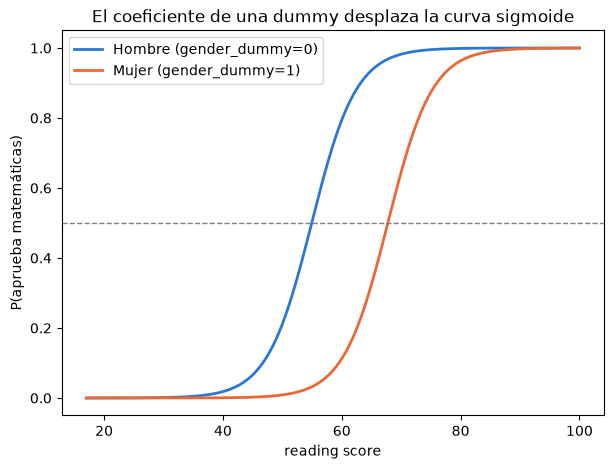

In [17]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

b0, b1, b2, b3 = modelo_logit.params
xs = np.linspace(df['reading score'].min(), df['reading score'].max(), 200)

# Fijamos test_prep_dummy=0 y comparamos hombre (gender_dummy=0) vs. mujer (gender_dummy=1)
p_hombre = sigmoide(b0 + b1 * xs + b2 * 0 + b3 * 0)
p_mujer = sigmoide(b0 + b1 * xs + b2 * 1 + b3 * 0)

plt.plot(xs, p_hombre, color='#2a78d6', linewidth=2, label='Hombre (gender_dummy=0)')
plt.plot(xs, p_mujer, color='#eb6834', linewidth=2, label='Mujer (gender_dummy=1)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('reading score')
plt.ylabel('P(aprueba matemáticas)')
plt.title('El coeficiente de una dummy desplaza la curva sigmoide')
plt.legend()
plt.show()

Este gráfico resume, de forma visual, qué hace un coeficiente categórico en una regresión logística: **no cambia la forma de la curva** (sigue siendo una "S"), la **desplaza** hacia la izquierda o la derecha. Con el mismo `reading score`, la curva de mujeres queda por debajo de la de hombres — el mismo efecto que leímos en el odds ratio, ahora visualmente.

## 9. Evaluar el clasificador

Igual que en el paso 6 del flujo de `01_Regresion_logistica_conceptos_basicos.md`: convertimos la probabilidad en una decisión (umbral 0.5) y construimos la matriz de confusión.

In [18]:
prob_predicha = modelo_logit.predict(X_log)
clase_predicha = (prob_predicha >= 0.5).astype(int)

cm = confusion_matrix(y_log, clase_predicha)
print('Matriz de confusión:')
print(pd.DataFrame(cm, index=['Real: no aprueba', 'Real: aprueba'], columns=['Predicho: no aprueba', 'Predicho: aprueba']))

exactitud = accuracy_score(y_log, clase_predicha)
precision = precision_score(y_log, clase_predicha)
recall = recall_score(y_log, clase_predicha)
print(f'\nExactitud (accuracy) = {exactitud:.4f}')
print(f'Precisión            = {precision:.4f}')
print(f'Sensibilidad (recall) = {recall:.4f}')

Matriz de confusión:
                  Predicho: no aprueba  Predicho: aprueba
Real: no aprueba                   252                 71
Real: aprueba                       46                631

Exactitud (accuracy) = 0.8830
Precisión            = 0.8989
Sensibilidad (recall) = 0.9321


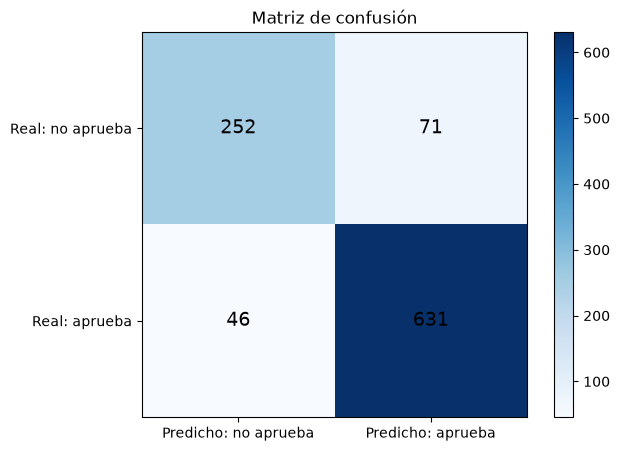

In [19]:
plt.imshow(cm, cmap='Blues')
plt.xticks([0, 1], ['Predicho: no aprueba', 'Predicho: aprueba'])
plt.yticks([0, 1], ['Real: no aprueba', 'Real: aprueba'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=14)
plt.title('Matriz de confusión')
plt.colorbar()
plt.show()

Con `reading score` + `gender_dummy` + `test_prep_dummy`, la exactitud (**~88.3%**) es más alta que la del modelo de una sola variable de `01_Regresion_logistica_conceptos_basicos.md` (~83.2% usando solo `reading score`). Agregar las dos variables categóricas sí mejoró la clasificación de forma perceptible — a diferencia del caso de regresión lineal de la sección 5, donde `parental level of education` apenas movió el R².

## 10. Comparación final

Resumen de todos los modelos ajustados en este notebook, siguiendo la misma tabla comparativa de `04_Regresion_Lineal_Vs_Regresion_Logistica.md`:

In [20]:
resumen = pd.DataFrame([
    {'Modelo': 'Lineal: writing ~ gender (dummy)', 'Tipo Y': 'numérica', 'Métrica': 'R²', 'Valor': round(modelo_dummy.rsquared, 4)},
    {'Modelo': 'Lineal: math ~ race/ethnicity (one-hot)', 'Tipo Y': 'numérica', 'Métrica': 'R²', 'Valor': round(modelo_race.rsquared, 4)},
    {'Modelo': 'Lineal: writing ~ reading + parental education (mixto)', 'Tipo Y': 'numérica', 'Métrica': 'R²', 'Valor': round(modelo_mixto.rsquared, 4)},
    {'Modelo': 'Logística: aprueba_mate ~ reading + gender + test_prep', 'Tipo Y': 'binaria', 'Métrica': 'Exactitud', 'Valor': round(exactitud, 4)},
])
resumen

,Modelo,Tipo Y,Métrica,Valor
0,Lineal: writing ~ gender (dummy),numérica,R²,0.0907
1,Lineal: math ~ race/ethnicity (one-hot),numérica,R²,0.0554
2,Lineal: writing ~ reading + parental education...,numérica,R²,0.9153
3,Logística: aprueba_mate ~ reading + gender + t...,binaria,Exactitud,0.8830


### Ejercicios de repaso

**Ejercicio 1.** El modelo de la sección 3 (`math score ~ race/ethnicity`) tiene R² = 0.055, mientras que el de la Semana 7 (`reading score` → `writing score`) tiene R² ≈ 0.91. ¿Por qué una variable categórica puede explicar mucho menos que una numérica bien elegida, aunque ambas sean estadísticamente significativas?

<details>
<summary>Ver solución</summary>

Que un coeficiente sea significativo (p-value bajo) solo dice que el efecto probablemente no es cero; no dice nada sobre **qué tan grande** es ese efecto ni cuánta variación total explica. `race/ethnicity` sí distingue algo entre grupos (por eso `group E` es significativo), pero la mayoría de la dispersión en `math score` ocurre **dentro** de cada grupo étnico, no **entre** grupos — por eso el R² es bajo. `reading score`, en cambio, se mueve de forma casi lineal con `writing score` estudiante por estudiante, capturando mucha más variación individual.

</details>

**Ejercicio 2.** Si quisieras predecir `writing score` usando **las 4 variables categóricas juntas** (`gender`, `race/ethnicity`, `parental level of education`, `lunch`) sin ninguna variable numérica, ¿qué deberías revisar antes de ajustar el modelo, según la sección 6 de este notebook?

<details>
<summary>Ver solución</summary>

Cuántas columnas dummy sumarían en total (aquí: 1 + 4 + 5 + 1 = 11 columnas nuevas para 1000 estudiantes) y si conviene reducir variables antes de ajustar — el mismo checklist de `02_Cuando_utilizar_modelo_regresion_lineal.md`. Con muchas columnas dummy y relativamente pocos datos, el modelo puede sobreajustarse y sus coeficientes volverse inestables y difíciles de interpretar.

</details>

**Ejercicio 3.** En la sección 8, el odds ratio de `gender_dummy` (≈0.033) parece "contradecir" que las mujeres tengan mejor `writing score` en promedio (sección 2). Explica por qué no es una contradicción.

<details>
<summary>Ver solución</summary>

Son dos preguntas distintas sobre dos variables distintas: la sección 2 compara promedios de `writing score` (una habilidad de lenguaje) entre géneros; la sección 8 compara la probabilidad de aprobar `math score` **controlando por `reading score`**. No hay ninguna regla que obligue a que el género tenga el mismo efecto (ni la misma dirección) sobre matemáticas que sobre escritura — de hecho, es un patrón real y conocido en datasets educativos como este: los coeficientes de un modelo siempre están condicionados a las variables que efectivamente incluye ese modelo específico.

</details>

## 11. Conclusiones

1. **Binaria → 1 dummy.** Una categórica de 2 niveles se convierte en una sola columna 0/1; su coeficiente en una regresión lineal es, literalmente, la diferencia de promedios entre los dos grupos (equivalente a una prueba *t*).
2. **Multinivel → *k*-1 dummies.** Cada nivel extra agrega una columna, y cada coeficiente se lee como "diferencia frente a la categoría de referencia" (la que quedó fuera).
3. **La dummy trap** existe porque incluir las *k* columnas completas (más el intercepto) crea multicolinealidad perfecta; por eso siempre se deja una fuera.
4. **Combinar categóricas y numéricas** en el mismo modelo es directo (se concatenan las columnas), pero cada categórica extra encarece la interpretación y el riesgo de sobreajuste — hay que justificar cada una, no solo agregarla porque "sube un poco el R²".
5. **Cuando la variable a predecir es categórica**, se sale de la regresión lineal y se entra a la regresión logística; ahí los coeficientes (incluidos los de las dummies) se interpretan mejor con el *odds ratio* ($e^b$), y el modelo se evalúa con matriz de confusión, no con R².
6. **Un coeficiente vive dentro de su modelo.** El mismo `gender` puede tener un efecto positivo grande sobre `writing score` y un efecto muy distinto sobre la probabilidad de aprobar matemáticas controlando por lectura — generalizar el efecto de una variable de un modelo a otro es un error común de interpretación.